# 07 · EDA orientado a actualizar el pronóstico

**Entra:** base analítica y fuentes limpias auxiliares de la única carpeta oficial. **No exporta datasets.**

Pregunta central: ¿la producción real reciente ayuda a anticipar el ajuste de las semanas siguientes, y qué añaden población, edad y clima? Primero calidad y cobertura; después asociación; finalmente comprobación predictiva en 09.

La unidad es tallos reportados. Las desviaciones frente al ingeniero son descriptivas hasta confirmar emisión y equivalencia de unidades. El archivo de erradicaciones WebFlor no se interpreta como una corrida conocida al origen.

## 1. Imports, carga y grano

In [1]:
from pathlib import Path
import sys
import re
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "Datos").is_dir() and (p / "Notebooks").is_dir())
SALIDA = ROOT / "Datos_analiticos_proyecto"
SALIDA.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 35)
print("Fuentes originales:", ROOT / "Datos")
print("Salida oficial:", SALIDA)

import matplotlib.pyplot as plt
base = pd.read_parquet(SALIDA/"base_analitica.parquet")
KEY = ["finca","producto","color","variedad"]
SEM = KEY+["semana_inicio"]
assert not base.duplicated(SEM).any()
print(base.shape,"Tallos:",int(base.tallos_reales.sum()))
print("Cobertura temporal:",base.semana_inicio.min(),base.semana_inicio.max())
display(base.head())


Fuentes originales: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos
Salida oficial: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos_analiticos_proyecto


(44053, 108) Tallos: 327991200
Cobertura temporal: 2021-01-04 00:00:00 2026-08-31 00:00:00


,finca,producto,color,variedad,semana_inicio,tallos_reales,registros_corte,dias_con_reporte,unidad,produccion_observada,anio,semana,temperatura_semana,humedad_semana,radiacion_semana,temperatura_min_semana,temperatura_max_semana,...,archivo_ingeniero_h5,archivo_posterior_ingeniero_h5,desfase_archivo_ingeniero_h5,metodo_union_ingeniero_h5,color_estimado_ingeniero_h5,conflicto_ingeniero_h5,cantidad_incompleta_ingeniero_h5,desviacion_ingeniero_h5,desviacion_pct_ingeniero_h5,equivalencia_exportable_confirmada,fecha_emision_ingeniero_confirmada,webflor_estado_descargado,siembras_webflor,conflicto_webflor,auditoria_webflor_min,auditoria_webflor_max,webflor_origen_certificado
0,GAITANA,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2023-07-17,60,1,1,tallos reportados,True,2023,29,14.109050,70.429336,126.250440,10.4,19.6,...,NaN,None,NaN,NaN,<NA>,None,None,<NA>,<NA>,False,False,NaN,NaN,None,NaT,NaT,False
1,GAITANA,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2023-07-24,185,4,3,tallos reportados,True,2023,30,14.804312,83.266147,173.424899,7.3,21.7,...,NaN,None,NaN,NaN,<NA>,None,None,<NA>,<NA>,False,False,NaN,NaN,None,NaT,NaT,False
2,GAITANA,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2023-07-31,180,3,3,tallos reportados,True,2023,31,14.229129,82.855750,169.997847,7.9,21.2,...,NaN,None,NaN,NaN,<NA>,None,None,<NA>,<NA>,False,False,NaN,NaN,None,NaT,NaT,False
3,GAITANA,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2023-08-07,120,2,2,tallos reportados,True,2023,32,13.980263,81.903518,177.054872,5.4,22.9,...,NaN,None,NaN,NaN,<NA>,None,None,<NA>,<NA>,False,False,NaN,NaN,None,NaT,NaT,False
4,GAITANA,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2023-08-21,60,1,1,tallos reportados,True,2023,34,14.460139,78.082566,219.175714,3.6,22.8,...,NaN,None,NaN,NaN,<NA>,None,None,<NA>,<NA>,False,False,NaN,NaN,None,NaT,NaT,False


## 2. Cobertura antes de interpretar una relación

Un faltante de plano, curva o estimado no borra la producción. Se muestran porcentajes por año; comparar modelos sobre subconjuntos distintos sin señalar cobertura produce conclusiones engañosas.

In [2]:
campos = ["tallos_reales","temperatura_semana","plantas_plano","edad_media_plano",
          "potencial_descriptivo","estimado_ingeniero_h1","estimado_ingeniero_h5","webflor_estado_descargado"]
display(base.groupby("anio")[campos].agg(lambda s:s.notna().mean()*100).round(1))
display(base[campos].describe().T)
series = base.groupby(KEY).agg(semanas_observadas=("semana_inicio","nunique"),
        desde=("semana_inicio","min"),hasta=("semana_inicio","max"),tallos=("tallos_reales","sum")).reset_index()
series["semanas_entre_extremos"] = (series.hasta-series.desde).dt.days//7+1
series["cobertura_calendario"] = series.semanas_observadas/series.semanas_entre_extremos
display(series.sort_values("tallos",ascending=False).head(20))
print("Series con >=104 observaciones y cobertura >=80% (candidatas, no garantía SARIMA):",
      int((series.semanas_observadas.ge(104)&series.cobertura_calendario.ge(.8)).sum()))


,tallos_reales,temperatura_semana,plantas_plano,edad_media_plano,potencial_descriptivo,estimado_ingeniero_h1,estimado_ingeniero_h5,webflor_estado_descargado
anio,,,,,,,,
2021,100.0,100.0,97.8,95.6,19.5,0.0,0.0,0.0
2022,100.0,100.0,96.1,94.1,18.8,0.0,0.0,0.0
2023,100.0,100.0,99.9,99.9,24.4,64.6,58.7,0.2
2024,100.0,100.0,99.8,99.3,22.6,81.8,82.0,0.6
2025,100.0,100.0,99.6,99.6,19.3,75.4,77.3,11.6
2026,100.0,88.6,93.1,93.1,17.4,70.4,70.0,51.3


,count,mean,std,min,25%,50%,75%,max
tallos_reales,44053.0,7445.377159,11622.91821,1.0,407.0,3130.0,8795.0,168051.0
temperatura_semana,43375.0,14.203027,0.941653,11.737595,13.616666,14.111445,14.714286,17.107816
plantas_plano,43152.0,57613.515689,81768.514969,1.0,4704.0,28782.0,67732.0,578752.0
edad_media_plano,42818.0,33.233577,13.123679,0.0,25.523001,32.034433,39.405282,173.0
potencial_descriptivo,9058.0,16671.877088,18460.306204,0.0,3745.512018,8352.234702,25000.144907,120904.068007
estimado_ingeniero_h1,21850.0,9448.554927,11295.917312,0.0,2310.0,5300.0,11850.0,101000.0
estimado_ingeniero_h5,21485.0,9493.671805,11143.192573,0.0,2400.0,5500.0,12000.0,103640.0
webflor_estado_descargado,4056.0,6259.484221,9311.75865,0.0,55.0,2903.0,7991.75,66599.0


,finca,producto,color,variedad,semanas_observadas,desde,hasta,tallos,semanas_entre_extremos,cobertura_calendario
543,GAITANA,MINICARNATION,YELLOW,CAESAR,295,2021-01-04,2026-08-31,15351002,296,0.996622
494,GAITANA,MINICARNATION,ORANGE,UCHUVA,295,2021-01-04,2026-08-31,15157543,296,0.996622
438,GAITANA,MINICARNATION,HOT PINK,PIGEON,295,2021-01-04,2026-08-31,12079285,296,0.996622
510,GAITANA,MINICARNATION,RED,DRACULA,295,2021-01-04,2026-08-31,11521712,296,0.996622
437,GAITANA,MINICARNATION,HOT PINK,LORENZO,295,2021-01-04,2026-08-31,11065154,296,0.996622
451,GAITANA,MINICARNATION,LAVENDER,NENUFAR,295,2021-01-04,2026-08-31,10807715,296,0.996622
483,GAITANA,MINICARNATION,LIGHT PINK,ZAGARA,295,2021-01-04,2026-08-31,9236738,296,0.996622
505,GAITANA,MINICARNATION,PURPLE,EPSILON,295,2021-01-04,2026-08-31,8311846,296,0.996622
460,GAITANA,MINICARNATION,LIGHT PINK,ACADEMY,238,2021-12-13,2026-08-31,7524232,247,0.963563
534,GAITANA,MINICARNATION,WHITE,NIMBUS,295,2021-01-04,2026-08-31,6777136,296,0.996622


Series con >=104 observaciones y cobertura >=80% (candidatas, no garantía SARIMA): 124


## 3. Producción y composición

Hipótesis: un total estable puede esconder cambios entre colores o variedades. Se reconcilian niveles por suma; una futura evaluación tendrá que medir cada nivel y no sólo el total.

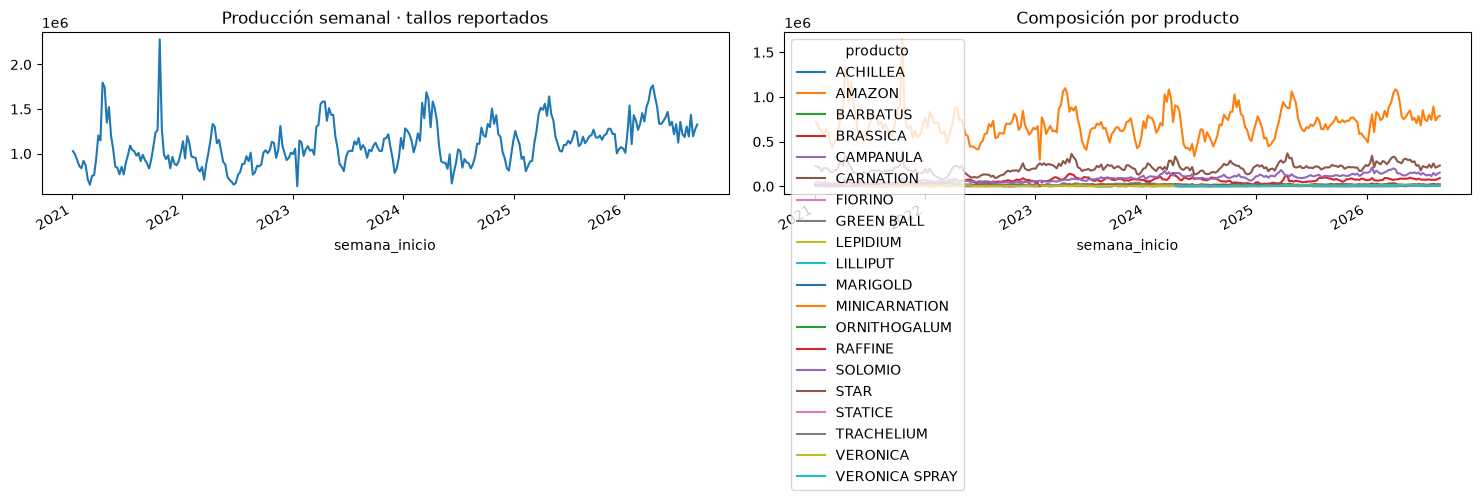

tallos
producto      color                     
MINICARNATION LIGHT PINK        25846208
              HOT PINK          23170496
              ORANGE            19518584
              YELLOW            18121578
              RED               17766299
              WHITE             16897487
              LAVENDER          12484333
              BICOLOR RED       11563351
              BICOLOR PINK       9078443
              PURPLE             8312658
CARNATION     WHITE              7556613
MINICARNATION CREAM              7353502
              GREEN              7244930
              PEACH              7099587
              BURGUNDY           6612885
              BICOLOR PURPLE     6082909
              BICOLOR YELLOW     5860054
GREEN BALL    GREEN              5839878
RAFFINE       BICOLOR BURGUNDY   5479294
CARNATION     ORANGE             4930748

,finca,producto,color,variedad,semanas_observadas,desde,hasta,tallos,semanas_entre_extremos,cobertura_calendario
543,GAITANA,MINICARNATION,YELLOW,CAESAR,295,2021-01-04,2026-08-31,15351002,296,0.996622
494,GAITANA,MINICARNATION,ORANGE,UCHUVA,295,2021-01-04,2026-08-31,15157543,296,0.996622
438,GAITANA,MINICARNATION,HOT PINK,PIGEON,295,2021-01-04,2026-08-31,12079285,296,0.996622
510,GAITANA,MINICARNATION,RED,DRACULA,295,2021-01-04,2026-08-31,11521712,296,0.996622
437,GAITANA,MINICARNATION,HOT PINK,LORENZO,295,2021-01-04,2026-08-31,11065154,296,0.996622
451,GAITANA,MINICARNATION,LAVENDER,NENUFAR,295,2021-01-04,2026-08-31,10807715,296,0.996622
483,GAITANA,MINICARNATION,LIGHT PINK,ZAGARA,295,2021-01-04,2026-08-31,9236738,296,0.996622
505,GAITANA,MINICARNATION,PURPLE,EPSILON,295,2021-01-04,2026-08-31,8311846,296,0.996622
460,GAITANA,MINICARNATION,LIGHT PINK,ACADEMY,238,2021-12-13,2026-08-31,7524232,247,0.963563
534,GAITANA,MINICARNATION,WHITE,NIMBUS,295,2021-01-04,2026-08-31,6777136,296,0.996622


In [3]:
semanal = base.groupby("semana_inicio").tallos_reales.sum()
por_producto = base.groupby(["semana_inicio","producto"]).tallos_reales.sum().unstack()
por_color = base.groupby(["producto","color"]).tallos_reales.sum().sort_values(ascending=False)
assert semanal.sum()==base.tallos_reales.sum()==por_color.sum()
fig,ax = plt.subplots(1,2,figsize=(15,4))
semanal.plot(ax=ax[0],title="Producción semanal · tallos reportados")
por_producto.plot(ax=ax[1],title="Composición por producto",legend=True)
plt.tight_layout();plt.show()
display(por_color.head(20).to_frame("tallos"))
display(series.sort_values("tallos",ascending=False).head(15))


## 4. Siembras, edad y potencial

Hipótesis agronómica: mayor población productiva y una mezcla de edades favorable se asocian con más producción. Una correlación agregada puede estar dominada por variedades grandes; se añade la asociación dentro de cada serie y se separa por año. El potencial aquí es descriptivo, no un pronóstico fuera de muestra.

,series,mediana_rho,min_rho,max_rho
variable,,,,
edad_media_plano,362,-0.164829,-0.963977,0.832167
humedad_semana,368,-0.063259,-0.727897,0.747476
plantas_plano,253,0.585180,-0.283726,0.966018
potencial_descriptivo,93,0.751957,-0.162218,0.969906
radiacion_semana,368,0.072139,-0.448195,0.595675
temperatura_semana,368,0.068529,-0.815505,0.742210


,,tallos_reales,plantas_plano,edad_media_plano,potencial_descriptivo,temperatura_semana,humedad_semana,radiacion_semana
anio,,,,,,,,
2021,tallos_reales,1.0,0.930880,-0.045865,0.907416,-0.043449,0.091532,-0.002040
2022,tallos_reales,1.0,0.939791,-0.041990,0.943583,-0.000450,-0.029983,-0.003061
2023,tallos_reales,1.0,0.942311,-0.155817,0.937068,0.017021,0.024693,0.009567
2024,tallos_reales,1.0,0.936989,-0.026299,0.926824,0.016264,-0.008301,0.022500
2025,tallos_reales,1.0,0.950177,0.087545,0.942799,0.048727,0.030535,-0.026848
2026,tallos_reales,1.0,0.955068,-0.198846,0.962976,-0.078856,0.083970,0.039059


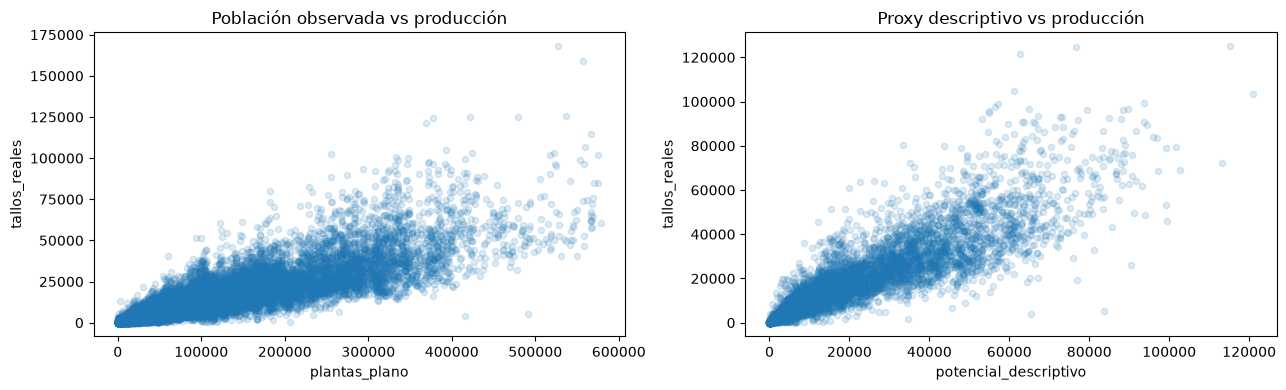

In [4]:
variables = ["plantas_plano","edad_media_plano","potencial_descriptivo",
             "temperatura_semana","humedad_semana","radiacion_semana"]
asociaciones = []
for keys,g in base.groupby(KEY):
    for v in variables:
        par = g[["tallos_reales",v]].dropna()
        if len(par)>=26 and par[v].nunique()>1 and par.tallos_reales.nunique()>1:
            asociaciones.append(dict(zip(KEY,keys))|{"variable":v,"n":len(par),
                                    "rho_spearman":par.tallos_reales.corr(par[v],method="spearman")})
asociaciones = pd.DataFrame(asociaciones)
display(asociaciones.groupby("variable").agg(series=("rho_spearman","size"),
        mediana_rho=("rho_spearman","median"),min_rho=("rho_spearman","min"),max_rho=("rho_spearman","max")))
display(base.groupby("anio")[["tallos_reales"]+variables].corr(method="spearman").loc[(slice(None),"tallos_reales"),:])
fig,ax=plt.subplots(1,2,figsize=(13,4))
base.plot.scatter(x="plantas_plano",y="tallos_reales",alpha=.15,ax=ax[0],title="Población observada vs producción")
base.plot.scatter(x="potencial_descriptivo",y="tallos_reales",alpha=.15,ax=ax[1],title="Proxy descriptivo vs producción")
plt.tight_layout();plt.show()


## 5. Ingeniero frente a producción observada

Se calcula real − estimado: positivo = estimación inferior al reportado. El WAPE usa volumen real y no es porcentaje de acierto por variedad. Cada horizonte se evalúa sólo donde hay pareja. Estos son diagnósticos condicionados, **no validación histórica certificada de producción exportable ni error WebFlor**.

La recuperación desde archivos posteriores se mantiene, como en la lógica original. Se muestran sus métricas separadas; no confundir ese reconstruido retrospectivo con un pronóstico emitido antes. También se distingue coincidencia estricta de recuperación 1:1 por variedad.

Las sumas con alguna cantidad fuente faltante quedan marcadas en la base y se excluyen de estas métricas: una suma parcial no representa el estimado completo. El horizonte de estas tablas se refiere a la solicitud, no necesariamente al archivo usado.


In [5]:
resumen = []
por_serie = []
for h in range(1,6):
    col = f"estimado_ingeniero_h{h}"
    completa = ~base[f"cantidad_incompleta_ingeniero_h{h}"].fillna(True).astype(bool)
    pares = base.loc[base[col].notna() & completa].copy()
    pares["desviacion"] = pares.tallos_reales-pares[col]
    pares["absoluta"] = pares.desviacion.abs()
    volumen = pares.tallos_reales.sum()
    resumen.append({"horizonte_solicitado":h,"parejas":len(pares),"cobertura_filas":len(pares)/len(base),
            "cantidades_incompletas_excluidas":int((base[col].notna() & ~completa).sum()),
            "sesgo_tallos":pares.desviacion.mean(),"MAE":pares.absoluta.mean(),
            "WAPE":pares.absoluta.sum()/volumen if volumen else np.nan})
    g = pares.groupby(KEY).agg(n=("desviacion","size"),real=("tallos_reales","sum"),
              error_abs=("absoluta","sum"),sesgo=("desviacion","mean")).reset_index()
    g["WAPE"] = g.error_abs/g.real.where(g.real.gt(0))
    g["horizonte_solicitado"] = h
    por_serie.append(g)
display(pd.DataFrame(resumen))
por_serie = pd.concat(por_serie,ignore_index=True)
display(por_serie.loc[por_serie.n.ge(10)].sort_values("WAPE",ascending=False).head(25))
display(por_serie.groupby("horizonte_solicitado").WAPE.agg(["median",lambda s:s.quantile(.9)]))

# Separar reconstrucciones con archivo posterior de referencias del archivo nominal.
# Ambas sirven para inspección; no se anuncian como validación predictiva.
control_recuperacion = []
for h in range(1,6):
    col = f"estimado_ingeniero_h{h}"
    completa = ~base[f"cantidad_incompleta_ingeniero_h{h}"].fillna(True).astype(bool)
    pares = base.loc[base[col].notna() & completa].copy()
    pares["desviacion"] = pares.tallos_reales-pares[col]
    pares["absoluta"] = pares.desviacion.abs()
    g = pares.groupby([f"archivo_posterior_ingeniero_h{h}",f"metodo_union_ingeniero_h{h}"],dropna=False).agg(
        parejas=("tallos_reales","size"),real=("tallos_reales","sum"),error_abs=("absoluta","sum"),sesgo=("desviacion","mean")).reset_index()
    g = g.rename(columns={f"archivo_posterior_ingeniero_h{h}":"archivo_posterior",f"metodo_union_ingeniero_h{h}":"metodo_union"})
    g["horizonte"] = h
    g["WAPE_descriptivo"] = g.error_abs/g.real.where(g.real.gt(0))
    control_recuperacion.append(g)
display(pd.concat(control_recuperacion,ignore_index=True))


,horizonte_solicitado,parejas,cobertura_filas,cantidades_incompletas_excluidas,sesgo_tallos,MAE,WAPE
0,1,21850,0.495993,0,640.752075,2099.096035,0.208052
1,2,22039,0.500284,0,623.911635,2368.527884,0.234839
2,3,21859,0.496198,0,647.379247,2500.380234,0.247200
3,4,21692,0.492407,0,676.182042,2561.054545,0.252159
4,5,21471,0.487390,14,699.375402,2600.997443,0.255048


,finca,producto,color,variedad,n,real,error_abs,sesgo,WAPE,horizonte_solicitado
633,GAITANA,CARNATION,GREEN,COUNTRY,15,1746,36962.0,-2239.6,21.16953,4
827,GAITANA,CARNATION,GREEN,COUNTRY,14,1526,28304.0,-1816.714286,18.547837,5
437,GAITANA,CARNATION,GREEN,COUNTRY,16,1998,27252.0,-1497.625,13.63964,3
241,GAITANA,CARNATION,GREEN,COUNTRY,17,2283,20309.0,-999.235294,8.895751,2
923,GAITANA,MINICARNATION,ORANGE,LINA,12,33963,111767.0,-6216.416667,3.290846,5
729,GAITANA,MINICARNATION,ORANGE,LINA,13,39075,119709.0,-6533.461538,3.06357,4
533,GAITANA,MINICARNATION,ORANGE,LINA,14,39520,117874.0,-6222.142857,2.982642,3
681,GAITANA,CARNATION,WHITE,KILIMANJARO,14,7852,22724.0,-939.857143,2.89404,4
485,GAITANA,CARNATION,WHITE,KILIMANJARO,15,9468,24492.0,-926.8,2.586819,3
843,GAITANA,CARNATION,ORANGE,ALHAMBRA,33,15121,31767.0,-810.272727,2.100853,5


,median,<lambda_0>
horizonte_solicitado,,
1,0.250438,0.578788
2,0.286378,0.604053
3,0.295306,0.608501
4,0.298469,0.682735
5,0.304296,0.718714


,archivo_posterior,metodo_union,parejas,real,error_abs,sesgo,horizonte,WAPE_descriptivo
0,False,coincide,19283,202854648,41861445.014825,682.457211,1,0.206362
1,False,unido_variedad,1170,4108532,1045444.35473,371.271321,1,0.254457
2,True,coincide,1322,13225354,2896215.0,302.412254,1,0.21899
3,True,unido_variedad,75,262824,62144.0,85.786667,1,0.236447
4,False,coincide,19119,201554418,47493145.338979,631.164634,2,0.235634
5,False,unido_variedad,1160,4082586,1174440.681134,398.080931,2,0.287671
6,True,coincide,1661,16315319,3450569.009074,721.121619,2,0.211493
7,True,unido_variedad,99,328010,81831.0,238.333333,2,0.249477
8,False,coincide,18949,200102605,49664011.574982,650.264024,3,0.248193
9,False,unido_variedad,1153,4057733,1229037.273492,416.923915,3,0.302888


## 6. Persistencia y rezagos: calendario regular, no salto entre registros

Hipótesis: la producción reciente y el clima pasado contienen señal. Se reindexa semanalmente antes de desplazar, dejando NaN si falta una semana. Las asociaciones son exploratorias; buscar muchos rezagos sobre todo el histórico no selecciona automáticamente un predictor validado.

In [6]:
resultados_lag = []
for keys,g in base.groupby(KEY):
    g = g.set_index("semana_inicio").sort_index()
    g = g.reindex(pd.date_range(g.index.min(),g.index.max(),freq="W-MON"))
    for variable in ["tallos_reales","temperatura_semana","humedad_semana","radiacion_semana"]:
        for lag in [1,2,4]:
            par = pd.concat([g.tallos_reales.rename("real"),g[variable].shift(lag).rename("pasado")],axis=1).dropna()
            if len(par)>=26 and par.real.nunique()>1 and par.pasado.nunique()>1:
                resultados_lag.append({"variable":variable,"rezago":lag,"n":len(par),
                              "rho":par.real.corr(par.pasado,method="spearman")})
lags = pd.DataFrame(resultados_lag)
display(lags.groupby(["variable","rezago"]).agg(series=("rho","size"),mediana_rho=("rho","median")))


series  mediana_rho
variable           rezago                     
humedad_semana     1          316    -0.059972
                   2          306    -0.059282
                   4          286    -0.064798
radiacion_semana   1          316     0.058623
                   2          306     0.040325
                   4          286     0.013512
tallos_reales      1          316     0.854843
                   2          306     0.733939
                   4          287     0.524123
temperatura_semana 1          316     0.106917
                   2          306     0.081986
                   4          286     0.102889

## 7. Calidad de las edades y qué significa una ausencia de producción

La diferencia con la edad al lunes no equivale a error: Excel usa AL1 y redondea. La fórmula ya se comprobó por libro en 04. El potencial sigue exigiendo soporte por variedad/edad y cobertura de plantas; no se relajan esos umbrales para aumentar coincidencias.

Un plano puede mostrar plantas en una semana sin corte reportado. Eso puede ser etapa improductiva o falta de reporte: no hay evidencia para convertir todas esas ausencias en cero.

In [7]:
planos = pd.read_parquet(SALIDA/"planos_siembra_limpio.parquet")
p = planos.loc[planos.finca.eq("GAITANA") & planos.edicion_elegida].copy()
display(p.groupby("anio_plano_fuente").agg(
    lineas=("fila_excel","size"),formula_reconocida=("formula_edad_reconocida","mean"),
    diferencia_con_lunes=("edad_diferente_al_lunes","mean"),inconsistencia_real=("edad_inconsistente","mean")))
por_edad = base.groupby("anio").agg(filas=("tallos_reales","size"),
    con_edad=("edad_media_plano","count"),con_potencial=("potencial_descriptivo","count"))
display(por_edad)
psem = p.dropna(subset=SEM).groupby(SEM).plantas.sum().reset_index()
revision = psem.merge(base[SEM+["tallos_reales"]],on=SEM,how="left",validate="one_to_one",indicator=True)
display(revision.groupby("_merge",observed=True).agg(
    combinaciones=("plantas","size"),plantas_estado_sumadas=("plantas","sum")))
print("Las combinaciones de plano sin reporte real NO se convierten automáticamente en cero.")
print("El total de plantas de esta tabla suma estados de distintas semanas: no plantas nuevas sembradas.")
print("Curvas: no extrapolar edades sin soporte ni elegir coeficientes SQL sin IdCurvaCiclo/vigencia.")
del planos,p,psem,revision


,lineas,formula_reconocida,diferencia_con_lunes,inconsistencia_real
anio_plano_fuente,,,,
2021,394304,1.0,0.470414,0.034377
2022,385024,1.0,0.514596,0.019113
2023,391781,1.0,0.524130,0.000309
2024,400451,1.0,0.496258,0.006792
2025,408566,1.0,0.478904,0.000000
2026,263374,1.0,0.401471,0.000304


,filas,con_edad,con_potencial
anio,,,
2021,6594,6306,1288
2022,7460,7017,1405
2023,8662,8654,2116
2024,7322,7269,1656
2025,8043,8010,1551
2026,5972,5562,1042


,combinaciones,plantas_estado_sumadas
_merge,,
left_only,16679,5.634166e+07
both,43152,2.486138e+09


Las combinaciones de plano sin reporte real NO se convierten automáticamente en cero.
El total de plantas de esta tabla suma estados de distintas semanas: no plantas nuevas sembradas.
Curvas: no extrapolar edades sin soporte ni elegir coeficientes SQL sin IdCurvaCiclo/vigencia.


## 8. Hipótesis central: la producción reciente orienta el siguiente ajuste

Medimos tres relaciones dentro de cada serie: producción pasada/futura, tendencia reciente/desviación respecto a media móvil, y persistencia de la desviación del ingeniero. Para un objetivo a H5, lo reciente se toma cinco semanas antes del objetivo, no de la semana inmediatamente anterior al objetivo.

Sólo el último análisis utiliza estimados y se restringe a parejas estrictas y archivos no posteriores. Aun así no acredita emisión. Correlación no demuestra capacidad predictiva: los modelos de 09 deben compararse fuera de entrenamiento.

series  mediana_rho  \
relacion                           horizonte                        
error_ingeniero_reciente_vs_futuro 1             153     0.459688   
                                   2             152     0.356437   
                                   3             152     0.232696   
                                   4             150     0.183214   
                                   5             149     0.120647   
produccion_reciente_vs_futura      1             316     0.854843   
                                   2             306     0.733939   
                                   3             295     0.617339   
                                   4             287     0.524123   
                                   5             273     0.455273   
tendencia_vs_error_media4          1             226     0.457432   
                                   2             225     0.322045   
                                   3             221     0.211395   
                                   4             217     0.119571   
                                   5             217     0.056144   

                                              fraccion_positiva  
relacion                           horizonte                     
error_ingeniero_reciente_vs_futuro 1                   1.000000  
                                   2                   0.973684  
                                   3                   0.973684  
                                   4                   0.880000  
                                   5                   0.832215  
produccion_reciente_vs_futura      1                   0.990506  
                                   2                   0.993464  
                                   3                   0.986441  
                                   4                   0.954704  
                                   5                   0.904762  
tendencia_vs_error_media4          1                   0.991150  
                                   2                   0.973333  
                                   3                   0.918552  
                                   4                   0.769585  
                                   5                   0.622120

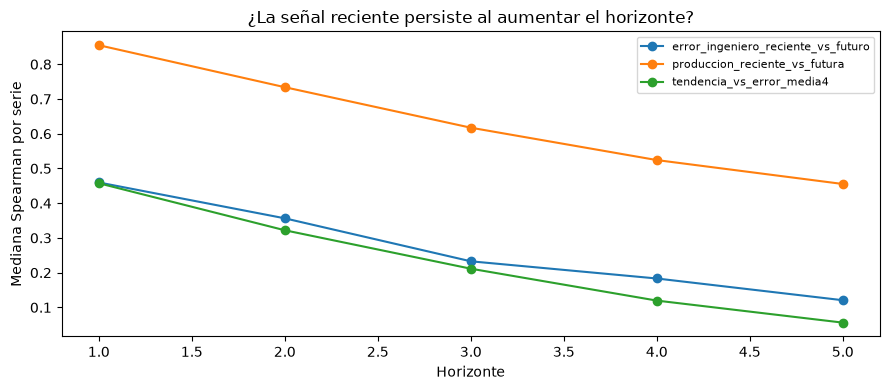

El error del ingeniero es diagnóstico retrospectivo: emisión y unidad todavía no certificadas.


In [8]:
actualizacion = []
for keys,g in base.groupby(KEY):
    g = g.set_index("semana_inicio").sort_index()
    g = g.reindex(pd.date_range(g.index.min(),g.index.max(),freq="W-MON"))
    real = g.tallos_reales
    error_h1 = (real-g.estimado_ingeniero_h1).where(
        g.archivo_posterior_ingeniero_h1.eq(False) &
        g.metodo_union_ingeniero_h1.eq("coincide") &
        g.cantidad_incompleta_ingeniero_h1.eq(False))
    for h in range(1,6):
        # En una fila objetivo u, origen=u-(h-1): la última semana cerrada es u-h.
        media_pasada = real.shift(h).rolling(4,min_periods=4).mean()
        ultima = real.shift(h)
        error_base = real-media_pasada
        tendencia = ultima-real.shift(h).rolling(8,min_periods=8).mean()
        error_ing = (real-g[f"estimado_ingeniero_h{h}"]).where(
            g[f"archivo_posterior_ingeniero_h{h}"].eq(False) &
            g[f"metodo_union_ingeniero_h{h}"].eq("coincide") &
            g[f"cantidad_incompleta_ingeniero_h{h}"].eq(False))
        pares = [
            ("produccion_reciente_vs_futura",ultima,real),
            ("tendencia_vs_error_media4",tendencia,error_base),
            ("error_ingeniero_reciente_vs_futuro",error_h1.shift(h),error_ing),
        ]
        for nombre,x,y in pares:
            par = pd.DataFrame({"x":x,"y":y}).dropna()
            if len(par)>=26 and par.x.nunique()>1 and par.y.nunique()>1:
                actualizacion.append(dict(zip(KEY,keys))|{"relacion":nombre,"horizonte":h,
                    "n":len(par),"rho":par.x.corr(par.y,method="spearman")})
actualizacion = pd.DataFrame(actualizacion)
display(actualizacion.groupby(["relacion","horizonte"]).agg(
    series=("rho","size"),mediana_rho=("rho","median"),fraccion_positiva=("rho",lambda s:s.gt(0).mean())))
fig,ax=plt.subplots(figsize=(9,4))
for nombre,g in actualizacion.groupby("relacion"):
    g.groupby("horizonte").rho.median().plot(marker="o",ax=ax,label=nombre)
ax.set(title="¿La señal reciente persiste al aumentar el horizonte?",ylabel="Mediana Spearman por serie",xlabel="Horizonte")
ax.legend(fontsize=8);plt.tight_layout();plt.show()
print("El error del ingeniero es diagnóstico retrospectivo: emisión y unidad todavía no certificadas.")


## 9. Conclusiones y decisión

**Hechos:** se conservan cantidades reales; la comparación de edad estaba usando referencias distintas y se corrigió con la fórmula fuente. Las tablas anteriores cuantifican cobertura y persistencia por horizonte.

**Hipótesis:** la memoria productiva permite actualizar el nivel esperado; población/edad y clima podrían explicar parte adicional. Un signo de correlación no demuestra causalidad.

**Decisión:** 09 ya compara sin memoria productiva, con memoria, con siembras y con clima sobre los mismos casos. Añadir una corrección a la media de cuatro semanas como demostración válida del ajuste; no llamarla corrección WebFlor.

**Pendientes:** publicación real de planos/ingeniero, equivalencia exportable/reportado, ausencia versus cero, representatividad de pilotos y vigencia del histórico WebFlor. La evaluación quedará condicionada a esos límites.